In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
# Load data
data = pd.read_excel("diabetes_frankurt_germany_1.xlsx")
print("Dataset shape:", data.shape)
data.head()

Dataset shape: (2000, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,2,138.0,62.0,35,0.0,33.6,0.127,47,1
1,0,84.0,82.0,31,125.0,38.2,0.233,23,0
2,0,145.0,72.0,29,126.0,44.2,0.630,31,1
3,0,135.0,68.0,42,250.0,42.3,0.365,24,1
4,1,139.0,62.0,41,480.0,40.7,0.536,21,0


In [5]:
# Cek missing values dan nilai 0 dan data duplikasi
# cek duplikat dan missing value
jumlah_duplikat = data.duplicated().sum()
data = data.drop_duplicates().reset_index(drop=True)
missing_values = data.isnull().sum()
print(f"Jumlah data duplikat: {jumlah_duplikat}")
print(f"Jumlah missing values:\n{missing_values}")

print("\nNilai 0 pada setiap kolom:")
jumlah_nol = {}
for kolom in data.columns:
    if kolom != 'Outcome':
        hitung_nol = (data[kolom] == 0).sum()
        jumlah_nol[kolom] = hitung_nol
        print(f"{kolom}: {hitung_nol}")

# Total baris yang memiliki minimal satu nilai 0 (selain Outcome)
fitur_dengan_nol = data.drop('Outcome', axis=1) == 0
total_baris_nol = fitur_dengan_nol.any(axis=1).sum()
print(f"\nTotal baris yang memiliki minimal satu nilai 0: {total_baris_nol}")
print(f"Persentase baris dengan nilai 0: {(total_baris_nol/len(data)*100):.2f}%")

Jumlah data duplikat: 8
Jumlah missing values:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

Nilai 0 pada setiap kolom:
Pregnancies: 301
Glucose: 4
BloodPressure: 32
SkinThickness: 175
Insulin: 313
BMI: 13
DiabetesPedigreeFunction: 0
Age: 0

Total baris yang memiliki minimal satu nilai 0: 571
Persentase baris dengan nilai 0: 28.66%


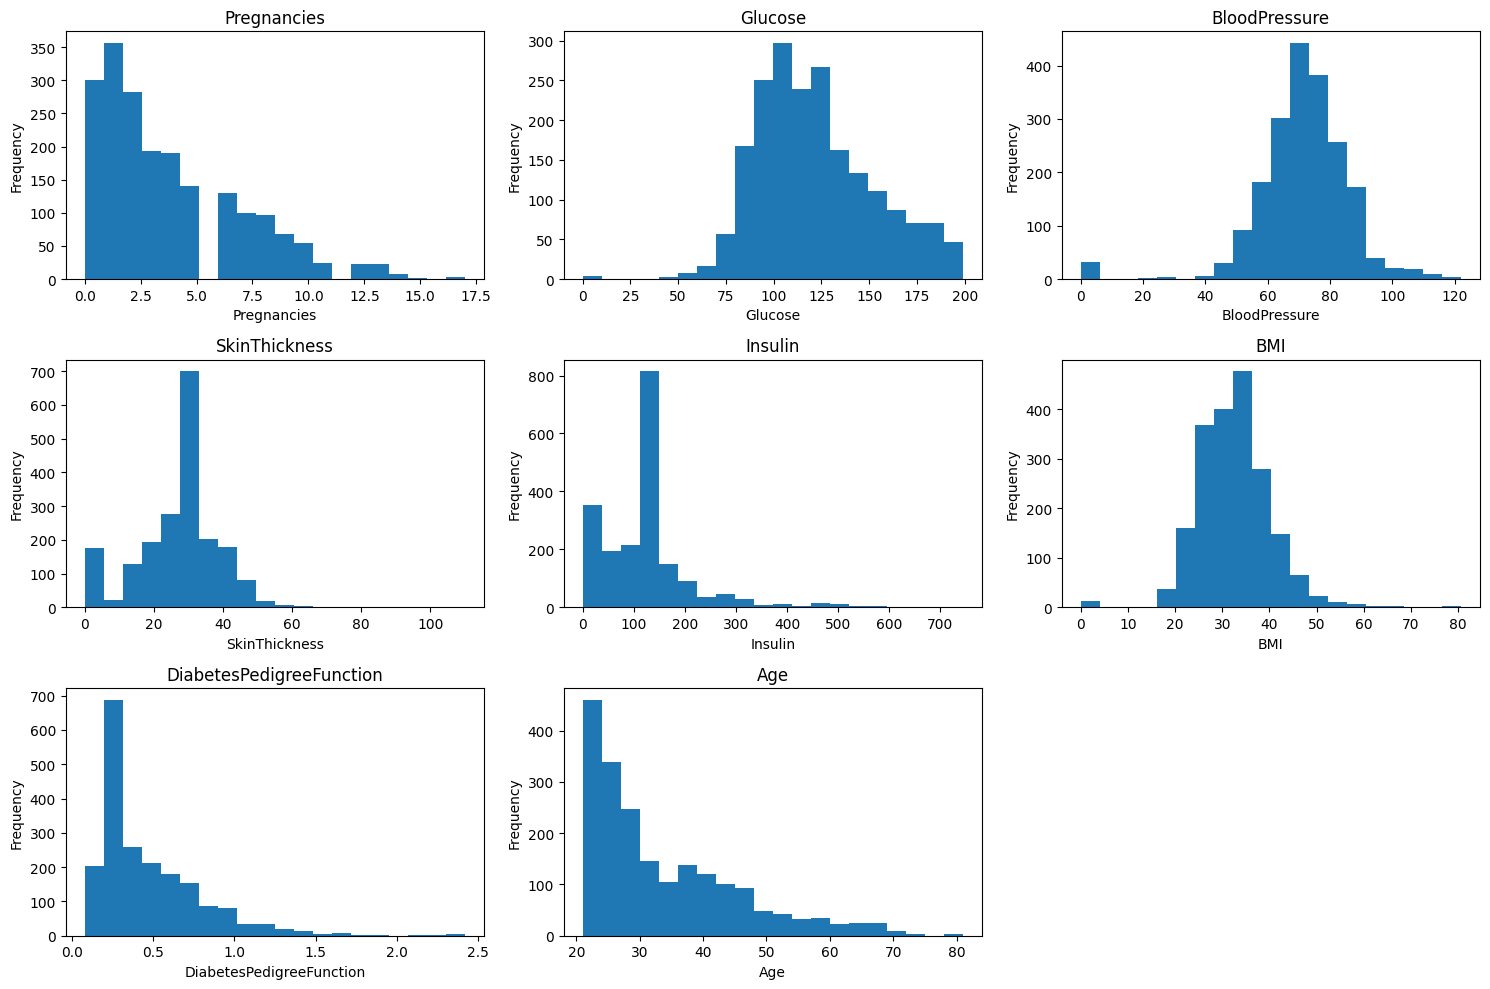

In [6]:
# Distribusi setiap fitur
plt.figure(figsize=(15, 10))
for i, kolom in enumerate(data.columns):
    if kolom == 'Outcome':
        continue
    plt.subplot(3, 3, i+1)
    plt.hist(data[kolom], bins=20)
    plt.title(kolom)
    plt.xlabel(kolom)
    plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

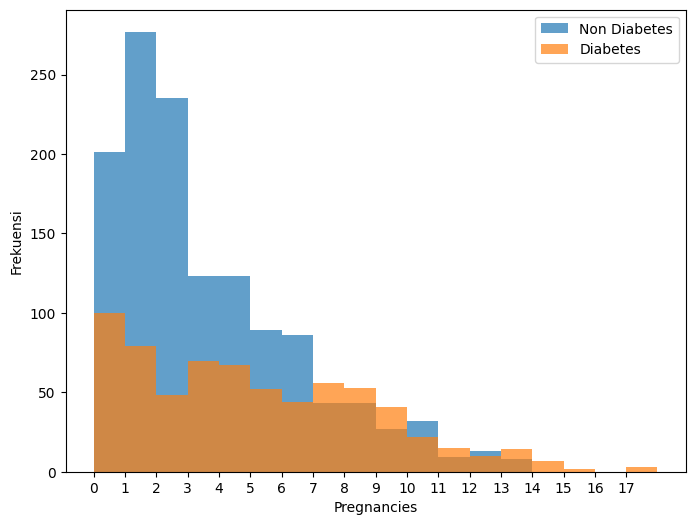

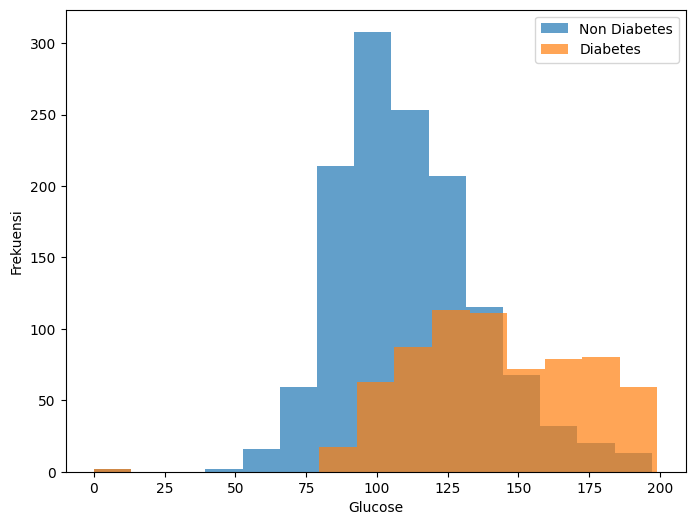

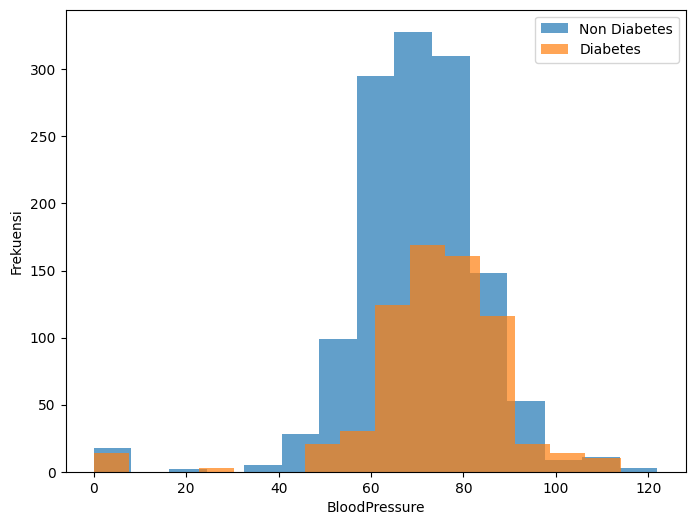

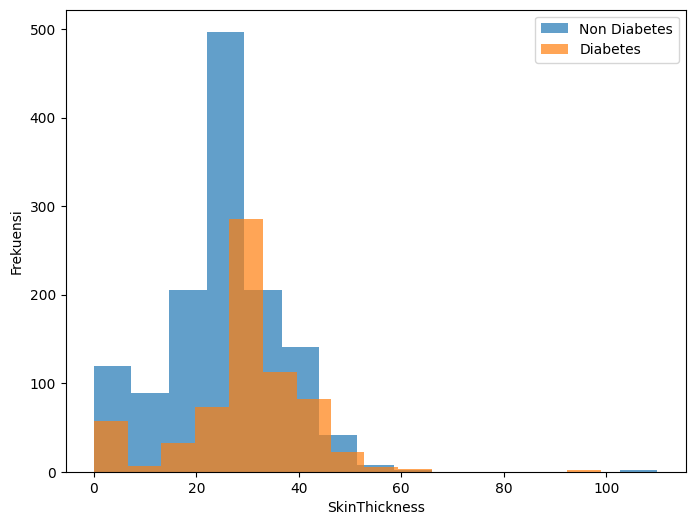

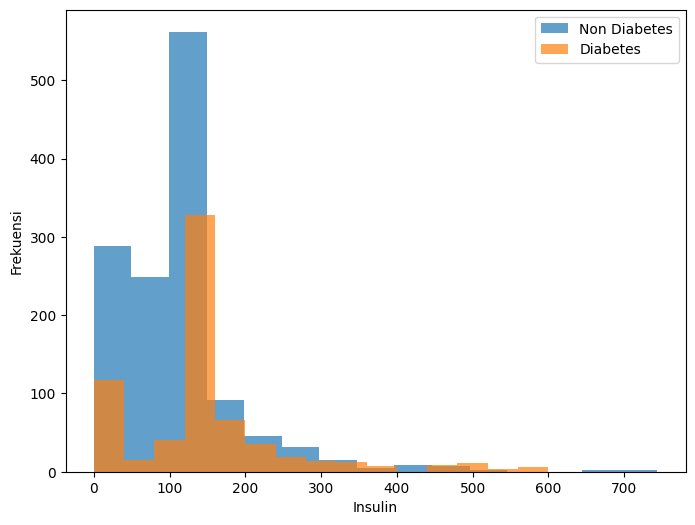

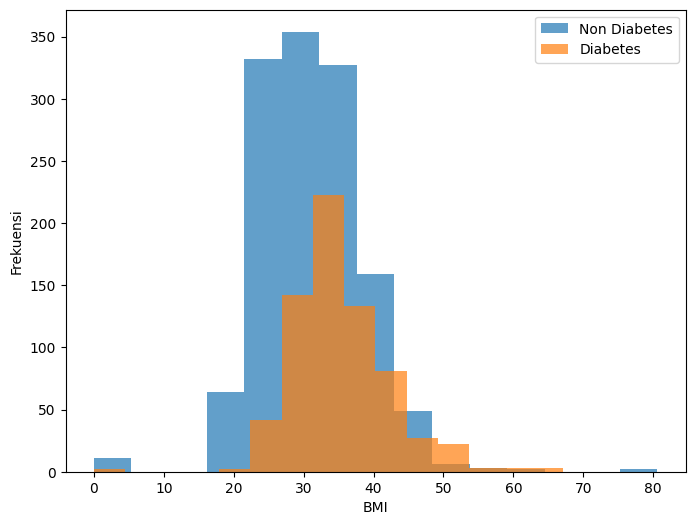

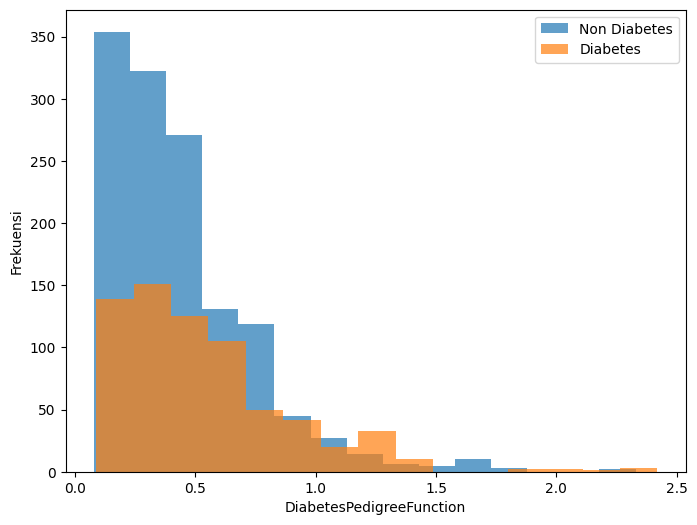

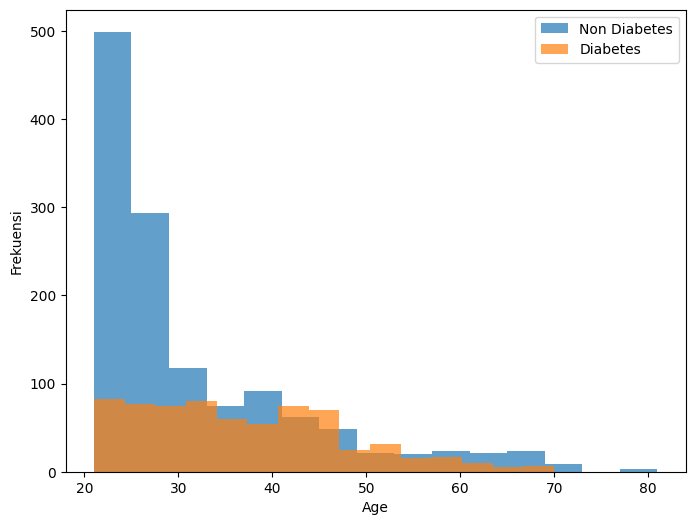

In [7]:
# Distribusi fitur terhadap target (Outcome) - satu per satu
features = data.columns[:-1]  # semua kecuali Outcome

for kolom in features:
    plt.figure(figsize=(8, 6))
    for outcome in [0, 1]:
        isi_data = data[data['Outcome'] == outcome][kolom]
        label = 'Non Diabetes' if outcome == 0 else 'Diabetes'
        if kolom == "Pregnancies":
            bins = range(int(data[kolom].min()), int(data[kolom].max()) + 2)
        else :
            bins = 15
        plt.hist(isi_data, alpha=0.7, label=label, bins=bins)
    plt.xlabel(kolom)
    plt.ylabel('Frekuensi')
    plt.legend()
    if kolom == "Pregnancies":
        plt.xticks(range(int(data[kolom].min()), int(data[kolom].max()) + 1))
    plt.show()

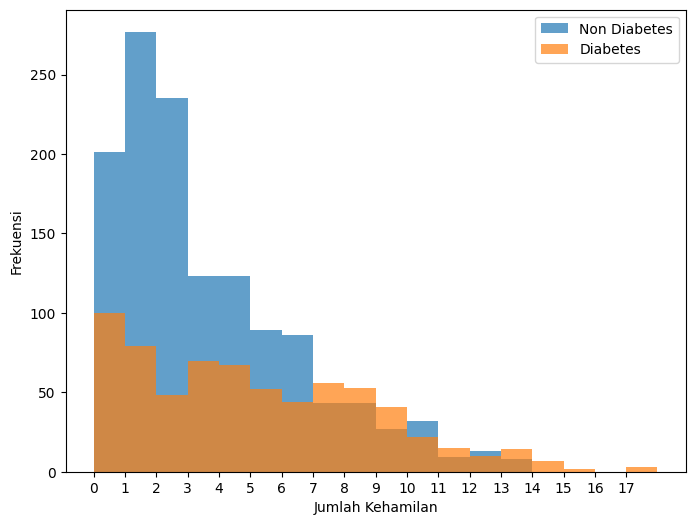

In [8]:
plt.figure(figsize=(8, 6))
for outcome in [0, 1]:
    isi_data = data[data['Outcome'] == outcome]['Pregnancies']
    label = 'Non Diabetes' if outcome == 0 else 'Diabetes'
    plt.hist(isi_data, alpha=0.7, label=label, bins=range(0, int(data['Pregnancies'].max()) + 2))
plt.xlabel('Jumlah Kehamilan')
plt.ylabel('Frekuensi')
plt.xticks(range(0, int(data['Pregnancies'].max()) + 1))
plt.legend()
plt.show()

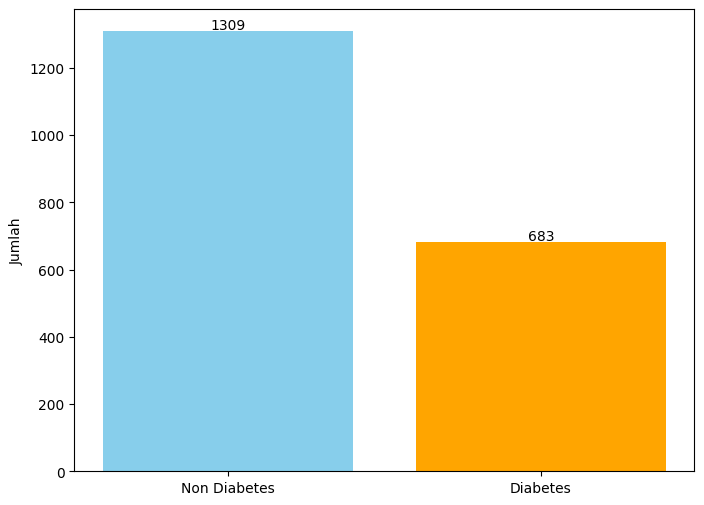

In [9]:
# Distribusi kelas pada target (Outcome)
plt.figure(figsize=(8, 6))
jumlah_outcome = data['Outcome'].value_counts()
plt.bar(jumlah_outcome.index, jumlah_outcome.values, color=['skyblue', 'orange'])
plt.ylabel('Jumlah')
plt.xticks([0, 1], ['Non Diabetes', 'Diabetes'])  # Menambahkan baris ini
for i, v in enumerate(jumlah_outcome.values):
    plt.text(i, v + 5, str(v), ha='center')
plt.show()